In [1]:
import torch
import argparse
import numpy as np
import matplotlib.pyplot as plt

from model.model import Model
from FlagEmbedding import BGEM3FlagModel

2025-04-21 00:57:10.149985: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-21 00:57:10.156676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745197030.164002  286131 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745197030.166223  286131 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745197030.172393  286131 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
def demo(model, context_bank, context_embed_bank, device):
    hist_series = np.sin(np.linspace(0, 8 * np.pi, 96)).tolist()
    hist_series = torch.Tensor(hist_series).unsqueeze(0).float().to(device)

    pred_result = []
    model.eval()
    with torch.no_grad():
        uni_pred_series = model(
            hist_series=hist_series, pred_len=24,
        ).cpu().numpy().reshape(-1)
        pred_result.append(uni_pred_series)

        for i, context in enumerate(context_bank):
            context_embed = torch.Tensor(context_embed_bank[i]).unsqueeze(0).float().to(device)
            multi_pred_series = model(
                hist_series=hist_series, pred_len=24, context_embed=context_embed
            ).cpu().numpy().reshape(-1)
            pred_result.append(multi_pred_series)

    hist_series = hist_series.cpu().numpy().reshape(-1)
    pred_result = np.array(pred_result)

    plt.figure(figsize=(10, 6), dpi=500)

    for i in range(len(context_bank)):
        plt.subplot(3, 3, i + 1)

        plt.plot(np.linspace(0, 95, 96), hist_series, color="#206CA6")
        plt.plot(np.linspace(96, 119, 24), pred_result[0], label="None", color="#206CA6")
        plt.plot(np.linspace(96, 119, 24), pred_result[i + 1], label="Text", color="#FE6D2E")

        plt.axvline(x=96, color="red", linestyle="--")
        plt.legend(loc=2)

        plt.title(context_bank[i])
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()

In [3]:
device = "cuda:0"
embed_path = "BAAI/bge-m3"
tsfm_path = "amazon/chronos-bolt-base"
pretrain_steer_path = "./log/ChronoSteer-base/checkpoint/pretrain_align_checkpoint.pth"
finetune_steer_path = "./log/ChronoSteer-base/checkpoint/finetune_align_checkpoint.pth"

parser = argparse.ArgumentParser("ChronoSteerer")
parser.add_argument("--series_dim", type=int, default=768)
parser.add_argument("--context_dim", type=int, default=1024)
parser.add_argument("--hidden_dim", type=int, default=1024)
parser.add_argument("--tsfm_path", type=str, default=tsfm_path)
args = parser.parse_args([])

In [4]:
context_bank = [
    "Keep Unchanged", "Increase Trend", "Reduce Trend",
    "Expand Amplitude", "Compress Amplitude", "Elevate Peaks",
    "Lower Peaks", "Raise Troughs", "Deepen Troughs",
]

context_embed_bank = []
embed_model = BGEM3FlagModel(embed_path)
for context in context_bank:
    context_embed_bank.append(embed_model.encode(context)["dense_vecs"].tolist())
context_embed_bank = np.array(context_embed_bank)

print(context_embed_bank.shape)

----------using 2*GPUs----------
(9, 1024)


In [5]:
model = Model(args=args, device=device, anchor_bank=context_embed_bank).to(device)

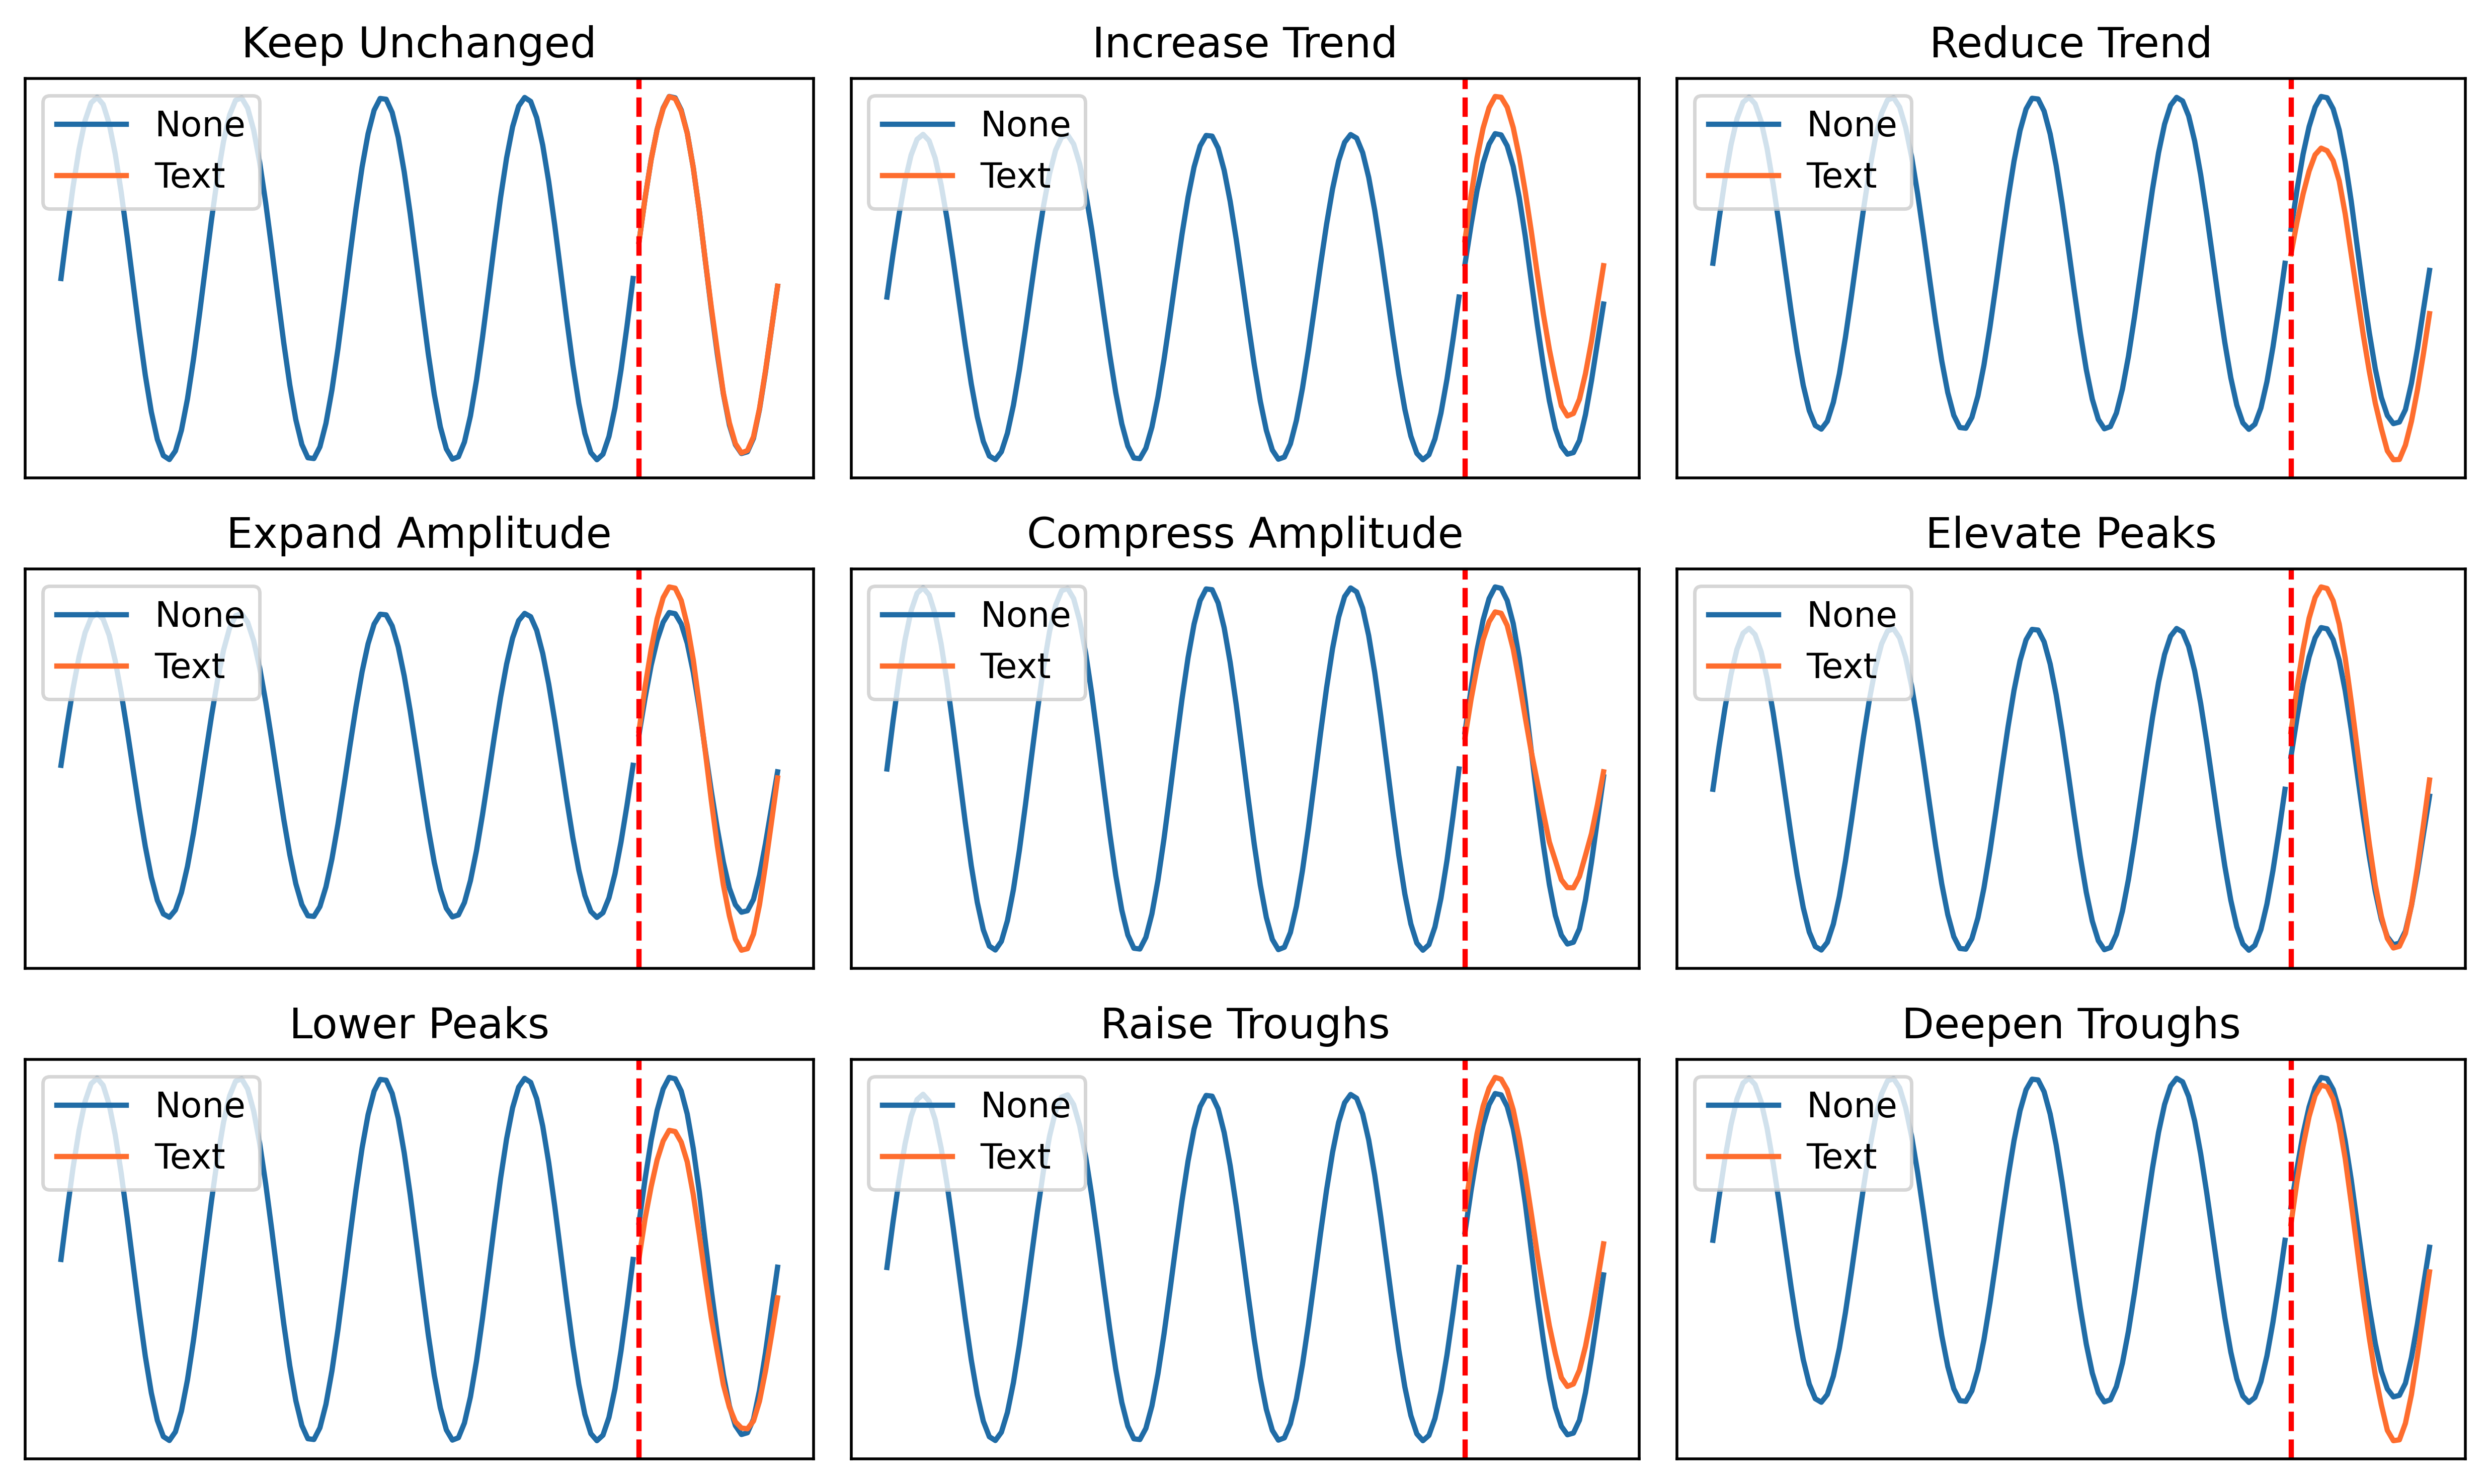

In [6]:
model.align.load_state_dict(torch.load(pretrain_steer_path, map_location=device))
demo(model, context_bank, context_embed_bank, device)

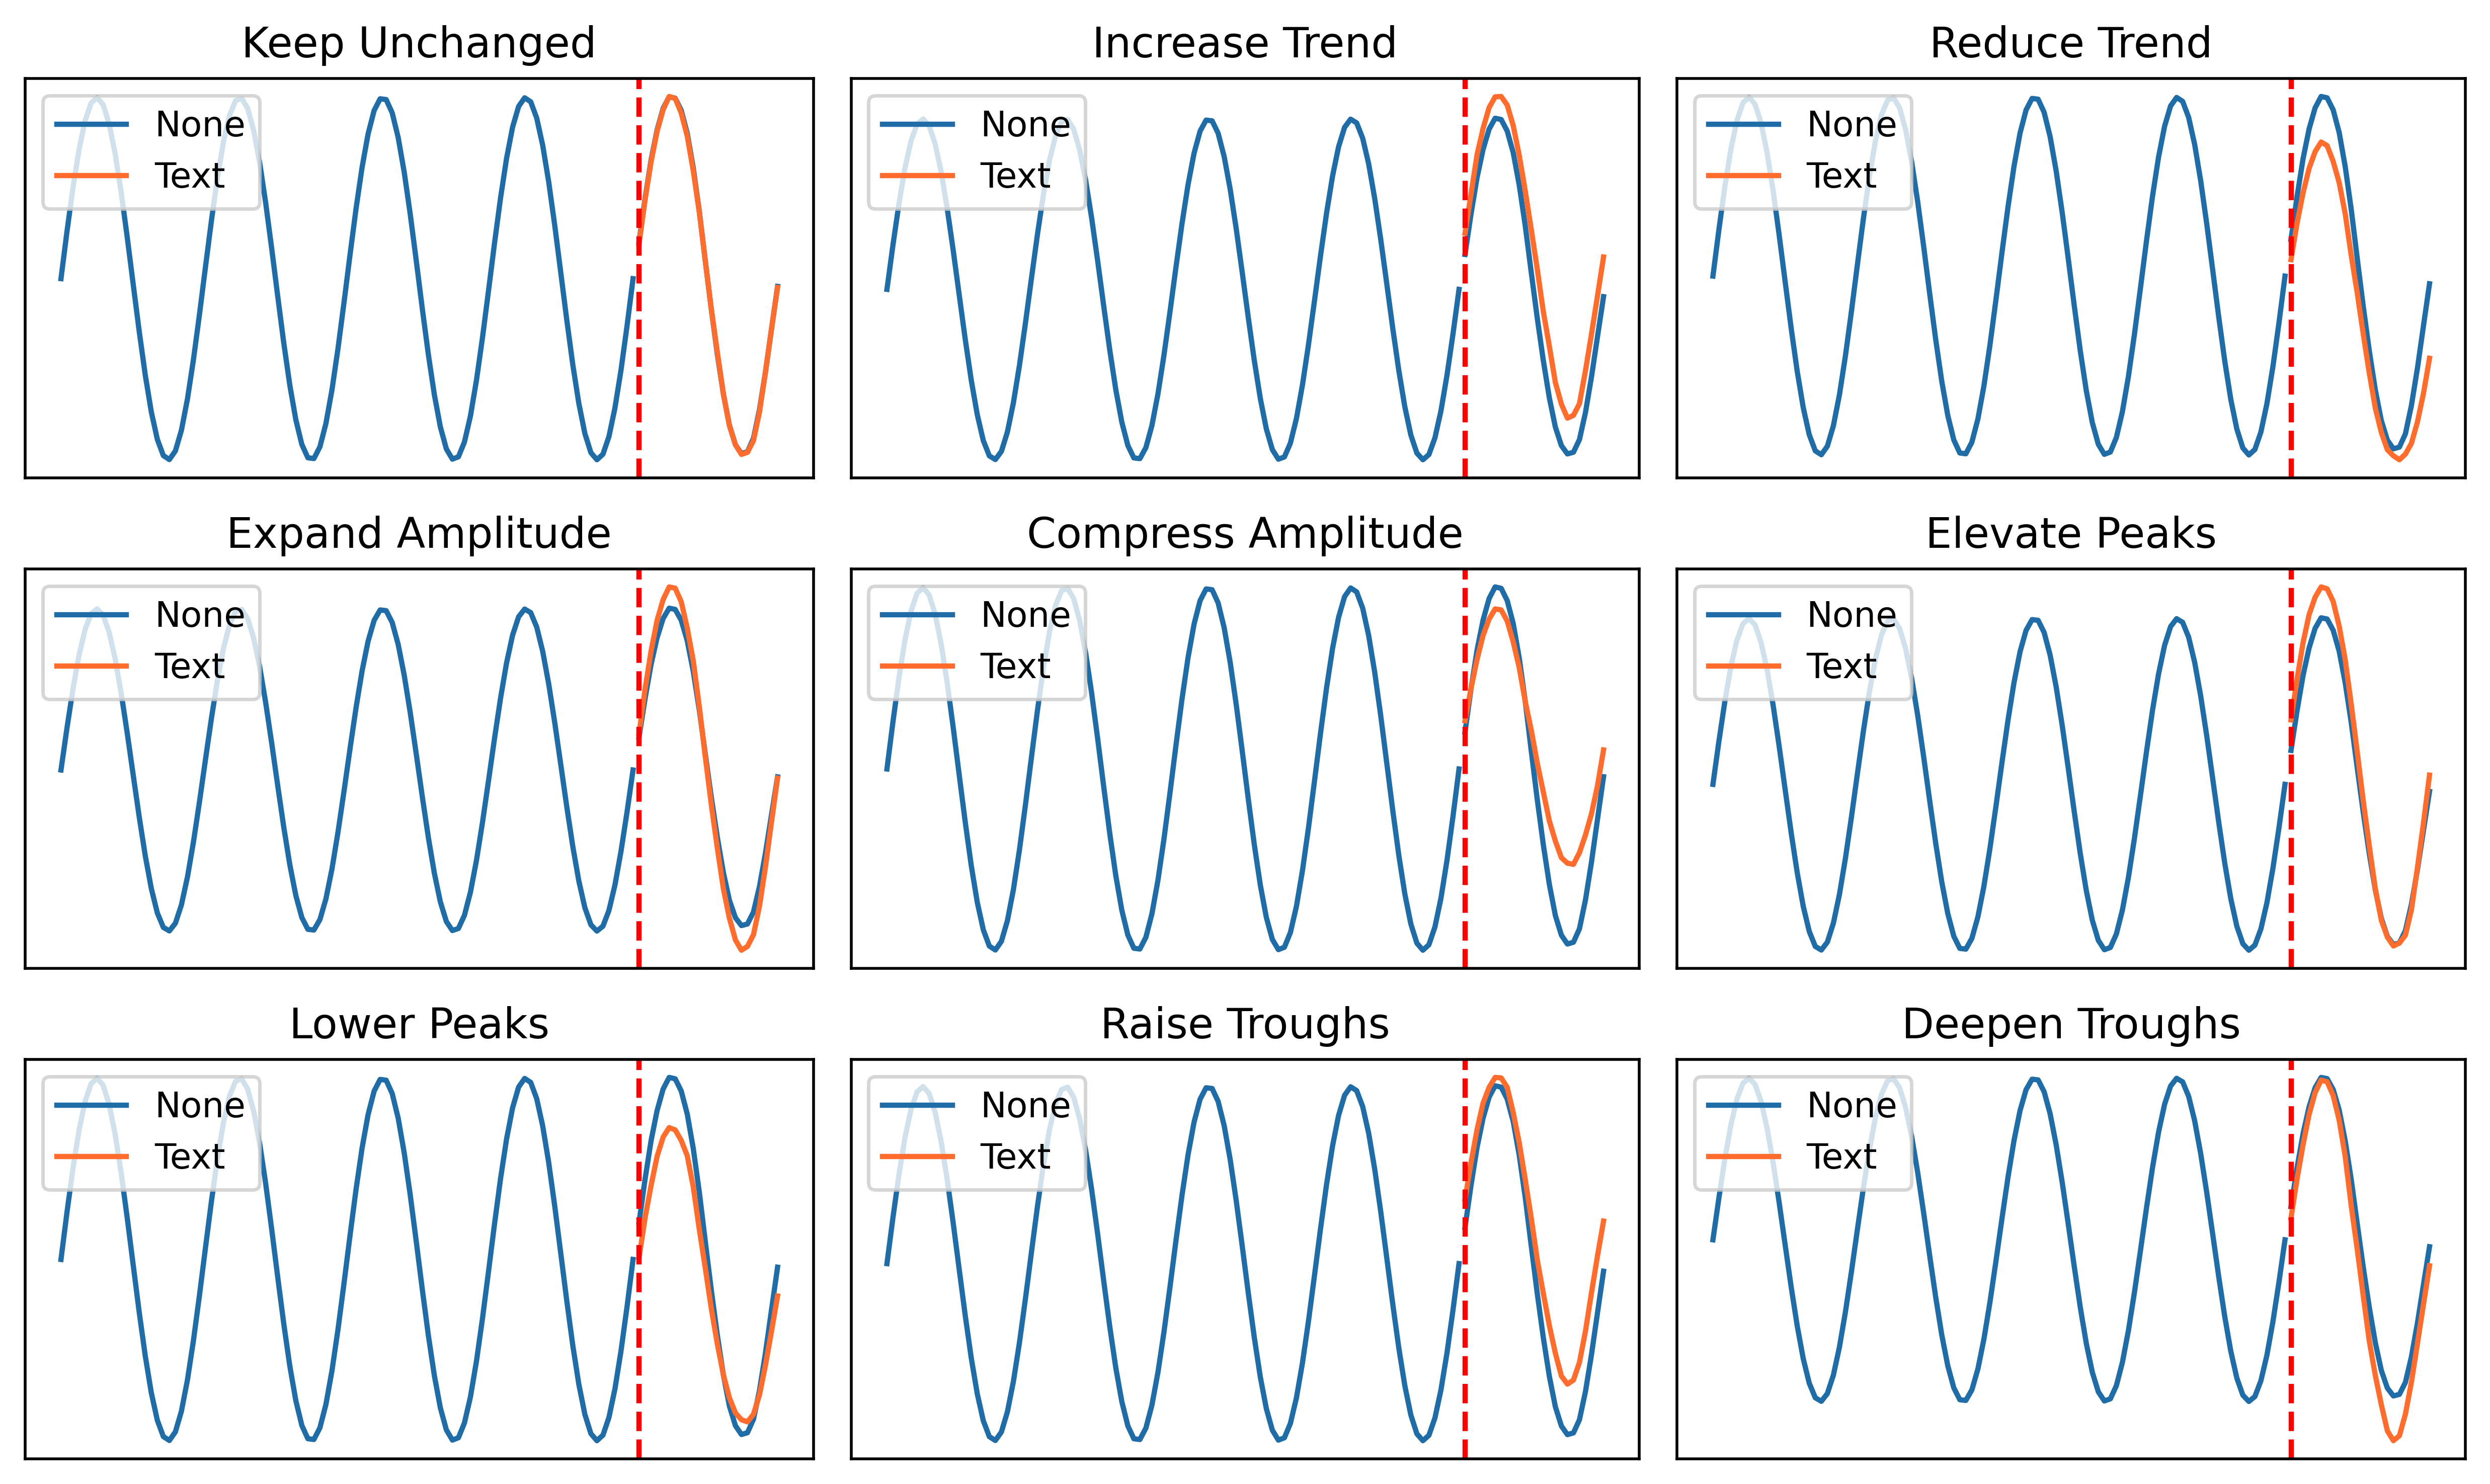

In [7]:
model.align.load_state_dict(torch.load(finetune_steer_path, map_location=device))
demo(model, context_bank, context_embed_bank, device)